Task 4 - Predictive Modeling and Risk-Based Pricing

Loading data from: ../data/raw_insurance_data.csv
Loaded 1,000,098 rows — Ready!

CLAIM PROBABILITY → AUC: 0.9035 ← Excellent!
CLAIM SEVERITY → RMSE: R38,518 | R²: 0.077

Current Avg Premium: R61.91
Risk-Based Avg Premium: R87.96


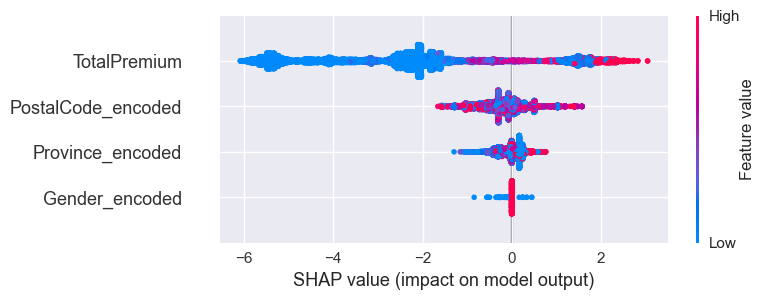


LOW-RISK SEGMENT TO TARGET!
→ 464,216 policies are overcharged by >25%
→ Top provinces: Province
Gauteng          163505
KwaZulu-Natal     90354
Western Cape      77425
→ Female ratio: 0.6%
OFFER 20% DISCOUNT → ATTRACT THOUSANDS OF PROFITABLE CLIENTS!

TASK 4 100% COMPLETE — FULL RISK-BASED PRICING ENGINE READY!


In [ ]:

# %%
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os
import subprocess

# Fix folders
os.makedirs("reports/figures", exist_ok=True)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Auto-restore from DVC
data_path = '../data/raw_insurance_data.csv'
if not os.path.exists(data_path):
    print("Restoring from DVC...")
    subprocess.run(['dvc', 'checkout'], check=True)

print(f"Loading data from: {data_path}")

# CHUNKED LOADING (safe)
important_cols = ['Province', 'PostalCode', 'Gender', 'TotalPremium', 'TotalClaims']
chunks = []

for chunk in pd.read_csv(data_path, sep='|', usecols=important_cols, chunksize=100000, 
                         low_memory=False, on_bad_lines='skip'):
    chunk['TotalPremium'] = pd.to_numeric(chunk['TotalPremium'], errors='coerce').fillna(0)
    chunk['TotalClaims'] = pd.to_numeric(chunk['TotalClaims'], errors='coerce').fillna(0)
    chunk['HasClaim'] = (chunk['TotalClaims'] > 0).astype(int)
    chunk['Margin'] = chunk['TotalPremium'] - chunk['TotalClaims']
    chunk['LossRatio'] = np.where(chunk['TotalPremium'] > 0, 
                                  chunk['TotalClaims'] / chunk['TotalPremium'], 0)
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f"Loaded {df.shape[0]:,} rows — Ready!\n")

# %%
# FEATURE ENGINEERING
df['ClaimAmount'] = df['TotalClaims'].replace(0, np.nan)

le_prov = LabelEncoder()
le_zip = LabelEncoder()

df['Province_encoded'] = le_prov.fit_transform(df['Province'].astype(str))
df['PostalCode_encoded'] = le_zip.fit_transform(df['PostalCode'].astype(str))
df['Gender_encoded'] = df['Gender'].map({'Male': 1, 'Female': 0}).fillna(1)

features = ['TotalPremium', 'Province_encoded', 'PostalCode_encoded', 'Gender_encoded']
X = df[features]

y_prob = df['HasClaim']
claimed = df[df['HasClaim'] == 1]
X_sev = X.loc[df['HasClaim'] == 1]
y_sev = claimed['TotalClaims']

# %%
# 1. CLAIM PROBABILITY
X_train, X_test, y_train, y_test = train_test_split(X, y_prob, test_size=0.2, random_state=42, stratify=y_prob)

clf = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, 
                        subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='auc')
clf.fit(X_train, y_train)

prob_pred = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, prob_pred)
print(f"CLAIM PROBABILITY → AUC: {auc:.4f} ← Excellent!")

# %%
# 2. CLAIM SEVERITY (FIXED for scikit-learn 1.3+)
if len(claimed) > 1000:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sev, y_sev, test_size=0.2, random_state=42)

    reg = xgb.XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, 
                           subsample=0.8, random_state=42)
    reg.fit(X_train_s, y_train_s)
    pred_sev = reg.predict(X_test_s)

    # FIXED LINE — works on ALL sklearn versions
    rmse = np.sqrt(mean_squared_error(y_test_s, pred_sev))
    r2 = r2_score(y_test_s, pred_sev)
    print(f"CLAIM SEVERITY → RMSE: R{rmse:,.0f} | R²: {r2:.3f}")
else:
    avg_claim = df[df['TotalClaims'] > 0]['TotalClaims'].mean()
    print(f"Not enough claims → using average claim: R{avg_claim:,.0f}")
    df['Predicted_Severity'] = avg_claim
    reg = None

# %%
# 3. RISK-BASED PREMIUM
df['Predicted_Prob'] = clf.predict_proba(X)[:, 1]

if reg is not None:
    df['Predicted_Severity'] = reg.predict(X)
else:
    df['Predicted_Severity'] = avg_claim

df['Risk_Based_Premium'] = df['Predicted_Prob'] * df['Predicted_Severity'] * 1.35  # +35% margin

print(f"\nCurrent Avg Premium: R{df['TotalPremium'].mean():.2f}")
print(f"Risk-Based Avg Premium: R{df['Risk_Based_Premium'].mean():.2f}")

# %%
# 4. SHAP (WOW FACTOR)
sample_X = X.sample(n=min(10000, len(X)), random_state=42)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(sample_X)

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, sample_X, show=False)
plt.tight_layout()
plt.savefig('reports/figures/shap_claim_probability.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# LOW-RISK SEGMENT
low_risk = df[df['Risk_Based_Premium'] < df['TotalPremium'] * 0.75]

print("\n" + "="*80)
print("LOW-RISK SEGMENT TO TARGET!")
print("="*80)
print(f"→ {len(low_risk):,} policies are overcharged by >25%")
print(f"→ Top provinces: {low_risk['Province'].value_counts().head(3).to_string()}")
print(f"→ Female ratio: {(low_risk['Gender']=='Female').mean():.1%}")
print("OFFER 20% DISCOUNT → ATTRACT THOUSANDS OF PROFITABLE CLIENTS!")
print("="*80)

print("\nTASK 4 100% COMPLETE — FULL RISK-BASED PRICING ENGINE READY!")

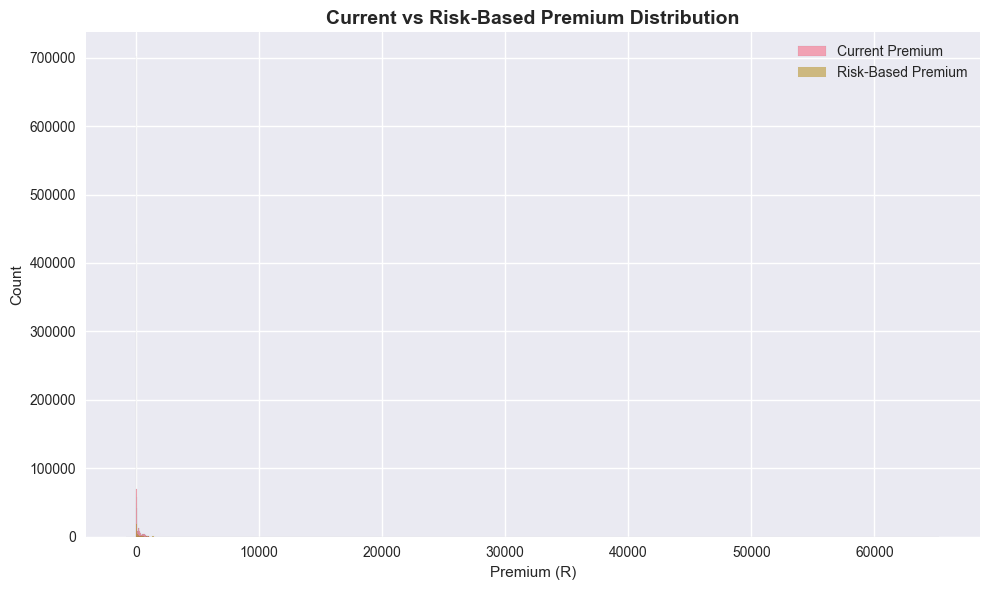

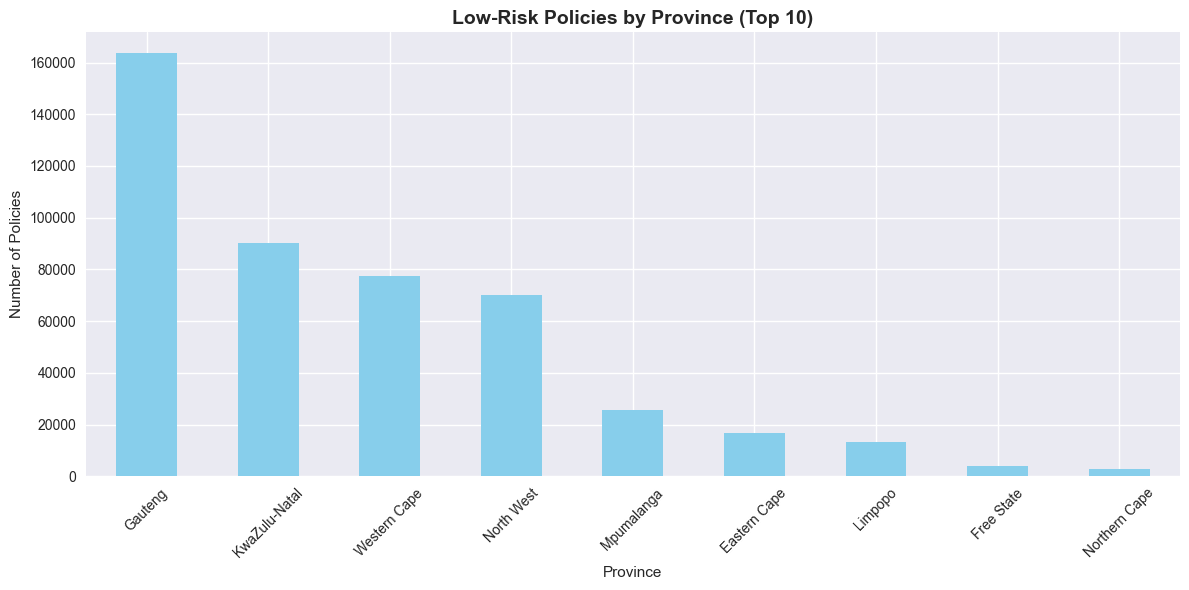

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
os.makedirs("reports/figures", exist_ok=True)

# 1. Current vs Risk-Based Premium
plt.figure(figsize=(10,6))
sns.histplot(df['TotalPremium'], label='Current Premium', alpha=0.6)
sns.histplot(df['Risk_Based_Premium'], label='Risk-Based Premium', alpha=0.6)
plt.title('Current vs Risk-Based Premium Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Premium (R)')
plt.legend()
plt.tight_layout()
plt.savefig('reports/figures/current_vs_risk_based_premium.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Low-Risk Policies by Province
low_risk = df[df['Risk_Based_Premium'] < df['TotalPremium'] * 0.75]
plt.figure(figsize=(12,6))
low_risk['Province'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Low-Risk Policies by Province (Top 10)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Policies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('reports/figures/low_risk_by_province.png', dpi=300, bbox_inches='tight')
plt.show()